
# 02_decoding_analysis_temporalAA_TRANSPOSED_within_from_npz.ipynb

This notebook mirrors the **across-condition temporal decoding notebook**, but for
**within-condition temporal AA** fits.

It assumes the fits were created with:
- `ANALYSIS_TYPE = "temporal"`
- `FIT_SCOPE = "within"`

so each condition has its own saved model per `K`.

## Conventions

Temporal AA here means:
- `sXC`: **V x K** spatial motifs
- `S`: **K x T** timecourse coefficients

Reconstruction back into original data space:
\[
\hat X = (sXC \cdot S)^	op
\]

All decoding is done on reconstructed `T x V` data.


In [18]:

LOAD_DIR = "msaa_flexible_outputs_npz"
K_VALUES = [10, 25, 50, 75, 100]
CONDITIONS = ["intact", "word", "rest"]

NFOLDS_DECODE = 2
NREPS_DECODE = 40
TOP_M_LIST = [1, 2, 3, 4, 5]
RNG_SEED = 42
ERRORBAR_TYPE = "sem"

COND_PLOT_COLORS = {"intact": "purple", "word": "green", "rest": "black"}


In [19]:

%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

print("Ready.")


Ready.


In [20]:

def to_float_array(x):
    return np.array(x, dtype=float)

def load_msaa_npz(path):
    data = np.load(path, allow_pickle=True)
    results_subj = data["results_subj"].tolist()
    if isinstance(results_subj, np.ndarray):
        results_subj = results_subj.tolist()
    return {
        "K": int(data["K"]),
        "results_subj": results_subj,
        "condition_labels_str": data["condition_labels_str"].tolist(),
        "condition_codes": data["condition_codes"],
        "condition_names": data["condition_names"].tolist() if "condition_names" in data else None,
        "analysis_type": data["analysis_type"].tolist() if "analysis_type" in data else "temporal",
        "fit_scope": data["fit_scope"].tolist() if "fit_scope" in data else "within",
    }

loaded = {}
for cond_name in CONDITIONS:
    loaded[cond_name] = {}
    for K in K_VALUES:
        path = os.path.join(LOAD_DIR, f"temporalAA_within_{cond_name}_K{K}.npz")
        loaded[cond_name][K] = load_msaa_npz(path)
        print("Loaded:", path)


Loaded: msaa_flexible_outputs_npz/temporalAA_within_intact_K10.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_intact_K25.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_intact_K50.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_intact_K75.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_intact_K100.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_word_K10.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_word_K25.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_word_K50.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_word_K75.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_word_K100.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_rest_K10.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_rest_K25.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_rest_K50.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_rest_K75.npz
Loaded: msaa_flexible_outputs_npz/temporalAA_within_rest_K100.npz


In [21]:

def decoder(corrs):
    out = pd.DataFrame({'rank':[0.0], 'accuracy':[0.0], 'error':[0.0]})
    T = corrs.shape[0]
    for t in range(T):
        decoded_ind = int(np.argmax(corrs[t, :]))
        out.loc[0, 'error'] += np.mean(np.abs(decoded_ind - t)) / T
        out.loc[0, 'accuracy'] += (decoded_ind == t)
        out.loc[0, 'rank'] += np.mean((corrs[t, :] <= corrs[t, t]).astype(int))
    out['error'] /= T
    out['accuracy'] /= T
    out['rank'] /= T
    return out

def get_xval_assignments(ndata, nfolds, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    group_assignments = np.zeros(ndata, dtype=int)
    groupsize = int(np.ceil(ndata / nfolds))
    for i in range(1, nfolds):
        inds = np.arange(i * groupsize, min((i + 1) * groupsize, ndata))
        group_assignments[inds] = i
    rng.shuffle(group_assignments)
    return group_assignments

def build_recon_stack(subjects, top_indices=None):
    Xhats = []
    for sub in subjects:
        sXC = to_float_array(sub["sXC"])   # V x K
        S = to_float_array(sub["S"])       # K x T
        Yhat = sXC @ S if top_indices is None else sXC[:, top_indices] @ S[top_indices, :]
        Xhat = Yhat.T
        Xhat = (Xhat - Xhat.mean(axis=0, keepdims=True)) / (Xhat.std(axis=0, keepdims=True) + 1e-8)
        Xhats.append(Xhat)
    return np.stack(Xhats, axis=0)

def run_timepoint_decoding(recon_stack, nfolds=2, nreps=20, seed=42):
    N, T, V = recon_stack.shape
    rng = np.random.default_rng(seed)
    all_results = []
    for rep in range(nreps):
        fold_ids = get_xval_assignments(N, nfolds, rng=rng)
        for i in range(nfolds):
            in_mask = (fold_ids == i)
            out_mask = ~in_mask
            in_mean = recon_stack[in_mask].mean(axis=0)
            out_mean = recon_stack[out_mask].mean(axis=0)
            corrs = 1.0 - cdist(in_mean, out_mean, metric='correlation')
            res = decoder(corrs)
            res["rep"] = rep
            res["fold"] = i
            all_results.append(res)
    return pd.concat(all_results, ignore_index=True)

def per_archetype_decoding(subjects, nfolds=2, nreps=20, seed=42):
    K = to_float_array(subjects[0]["S"]).shape[0]
    rows = []
    for k in range(K):
        recon_stack = build_recon_stack(subjects, top_indices=[k])
        res = run_timepoint_decoding(recon_stack, nfolds=nfolds, nreps=nreps, seed=seed)
        res["archetype"] = k
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

def run_timepoint_decoding_topm(subjects, ranked_indices, top_ms=(1,2,3,4,5), nfolds=2, nreps=20, seed=42):
    rows = []
    for m in top_ms:
        top_idx = ranked_indices[:m]
        recon_stack = build_recon_stack(subjects, top_indices=top_idx)
        res = run_timepoint_decoding(recon_stack, nfolds=nfolds, nreps=nreps, seed=seed)
        res["top_m"] = m
        rows.append(res)
    return pd.concat(rows, ignore_index=True)

def summarize_metric_with_error(df, metric_col, errorbar_type="sem", group_cols=None):
    group_cols = [] if group_cols is None else group_cols
    out = df.groupby(group_cols)[metric_col].agg(["mean", "std", "count"]).reset_index()
    if errorbar_type == "sem":
        out["err"] = out["std"] / np.sqrt(out["count"].clip(lower=1))
    elif errorbar_type == "std":
        out["err"] = out["std"]
    else:
        out["err"] = 1.96 * out["std"] / np.sqrt(out["count"].clip(lower=1))
    return out


In [22]:

full_recon_rows = []
topm_rows = []
global_rankings = {}
per_arch_summary_rows = []

for cond_name in CONDITIONS:
    for K in K_VALUES:
        cur = loaded[cond_name][K]
        results_subj = cur["results_subj"]

        # full reconstruction
        recon_stack = build_recon_stack(results_subj, top_indices=None)
        res_full = run_timepoint_decoding(recon_stack, nfolds=NFOLDS_DECODE, nreps=NREPS_DECODE, seed=RNG_SEED)
        res_full["K"] = K
        res_full["condition"] = cond_name
        res_full["reconstruction"] = "all_archetypes"
        full_recon_rows.append(res_full)

        # per-archetype ranking within each condition
        per_arch_all = per_archetype_decoding(results_subj, nfolds=NFOLDS_DECODE, nreps=NREPS_DECODE, seed=RNG_SEED)
        top_arch = per_arch_all.groupby("archetype")["accuracy"].mean().sort_values(ascending=False)
        global_rankings[(cond_name, K)] = top_arch.index.to_numpy()

        pa = top_arch.reset_index()
        pa.columns = ["archetype", "mean_accuracy"]
        pa["condition"] = cond_name
        pa["K"] = K
        per_arch_summary_rows.append(pa)

        # top-m reconstructions
        res_topm = run_timepoint_decoding_topm(
            results_subj,
            ranked_indices=global_rankings[(cond_name, K)],
            top_ms=TOP_M_LIST,
            nfolds=NFOLDS_DECODE,
            nreps=NREPS_DECODE,
            seed=RNG_SEED,
        )
        res_topm["K"] = K
        res_topm["condition"] = cond_name
        res_topm["reconstruction"] = "top_m_within_condition"
        topm_rows.append(res_topm)

full_recon_df = pd.concat(full_recon_rows, ignore_index=True)
topm_df = pd.concat(topm_rows, ignore_index=True)
per_arch_summary_df = pd.concat(per_arch_summary_rows, ignore_index=True)

display(full_recon_df.head())
display(topm_df.head())
display(per_arch_summary_df.head())


,rank,accuracy,error,rep,fold,K,condition,reconstruction
0,0.849089,0.056667,0.245922,0,0,10,intact,all_archetypes
1,0.851344,0.063333,0.191056,0,1,10,intact,all_archetypes
2,0.858744,0.063333,0.229756,1,0,10,intact,all_archetypes
3,0.857578,0.070000,0.239944,1,1,10,intact,all_archetypes
4,0.858889,0.053333,0.249056,2,0,10,intact,all_archetypes


,rank,accuracy,error,rep,fold,top_m,K,condition,reconstruction
0,0.695356,0.020000,0.258656,0,0,1,10,intact,top_m_within_condition
1,0.677311,0.006667,0.276867,0,1,1,10,intact,top_m_within_condition
2,0.663344,0.006667,0.251400,1,0,1,10,intact,top_m_within_condition
3,0.674178,0.006667,0.231289,1,1,1,10,intact,top_m_within_condition
4,0.678089,0.006667,0.269956,2,0,1,10,intact,top_m_within_condition


,archetype,mean_accuracy,condition,K
0,6,0.009958,intact,10
1,5,0.009375,intact,10
2,8,0.009375,intact,10
3,2,0.009292,intact,10
4,1,0.008958,intact,10


In [23]:

topm_archetypes_df = pd.DataFrame([
    {
        "condition": cond_name,
        "K": K,
        "top_m": m,
        "selected_archetypes": list(global_rankings[(cond_name, K)][:m]),
        "selected_archetypes_str": str(list(global_rankings[(cond_name, K)][:m])),
    }
    for cond_name in CONDITIONS
    for K in K_VALUES
    for m in TOP_M_LIST
])

full_summary = summarize_metric_with_error(
    full_recon_df, "accuracy", ERRORBAR_TYPE, ["condition", "K", "reconstruction"]
)
topm_summary = summarize_metric_with_error(
    topm_df, "accuracy", ERRORBAR_TYPE, ["condition", "K", "reconstruction", "top_m"]
)

best_topm_rows = []
for cond_name in CONDITIONS:
    for K in K_VALUES:
        sub = topm_summary[(topm_summary["condition"] == cond_name) & (topm_summary["K"] == K)]
        if len(sub):
            best_topm_rows.append(sub.loc[sub["mean"].idxmax()].copy())
best_topm_df = pd.DataFrame(best_topm_rows)

display(full_summary)
display(topm_summary.head())
display(best_topm_df)


,condition,K,reconstruction,mean,std,count,err
0,intact,10,all_archetypes,0.054625,0.009758,80,0.001091
1,intact,25,all_archetypes,0.099667,0.015100,80,0.001688
2,intact,50,all_archetypes,0.135375,0.019799,80,0.002214
3,intact,75,all_archetypes,0.163042,0.021927,80,0.002451
4,intact,100,all_archetypes,0.168958,0.025217,80,0.002819
5,rest,10,all_archetypes,0.007667,0.004482,80,0.000501
6,rest,25,all_archetypes,0.008750,0.003838,80,0.000429
7,rest,50,all_archetypes,0.009625,0.004276,80,0.000478
8,rest,75,all_archetypes,0.010083,0.004308,80,0.000482
9,rest,100,all_archetypes,0.010292,0.004506,80,0.000504


,condition,K,reconstruction,top_m,mean,std,count,err
0,intact,10,top_m_within_condition,1,0.009958,0.004259,80,0.000476
1,intact,10,top_m_within_condition,2,0.016875,0.005286,80,0.000591
2,intact,10,top_m_within_condition,3,0.022417,0.006666,80,0.000745
3,intact,10,top_m_within_condition,4,0.028458,0.006687,80,0.000748
4,intact,10,top_m_within_condition,5,0.033542,0.007142,80,0.000799


,condition,K,reconstruction,top_m,mean,std,count,err
4,intact,10,top_m_within_condition,5,0.033542,0.007142,80,0.000799
9,intact,25,top_m_within_condition,5,0.036000,0.008291,80,0.000927
14,intact,50,top_m_within_condition,5,0.028208,0.006092,80,0.000681
19,intact,75,top_m_within_condition,5,0.026875,0.005571,80,0.000623
24,intact,100,top_m_within_condition,5,0.026375,0.006190,80,0.000692
54,word,10,top_m_within_condition,5,0.025000,0.007233,80,0.000809
59,word,25,top_m_within_condition,5,0.024042,0.007050,80,0.000788
64,word,50,top_m_within_condition,5,0.024792,0.006705,80,0.000750
69,word,75,top_m_within_condition,5,0.018000,0.006487,80,0.000725
74,word,100,top_m_within_condition,5,0.016042,0.005117,80,0.000572


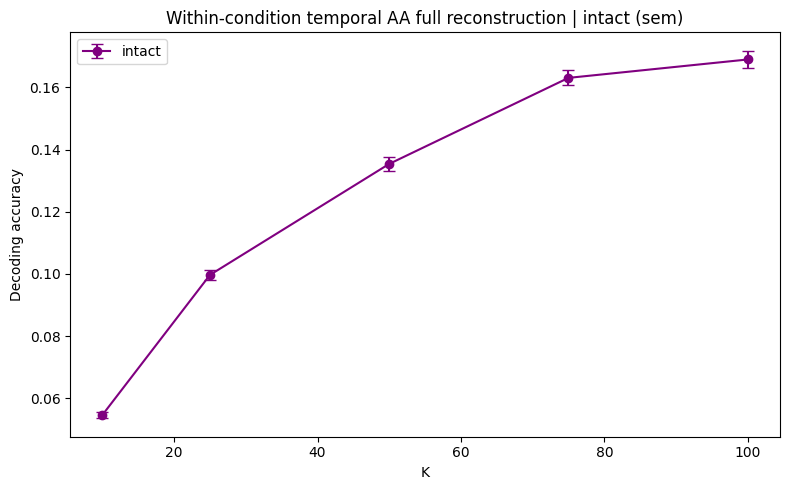

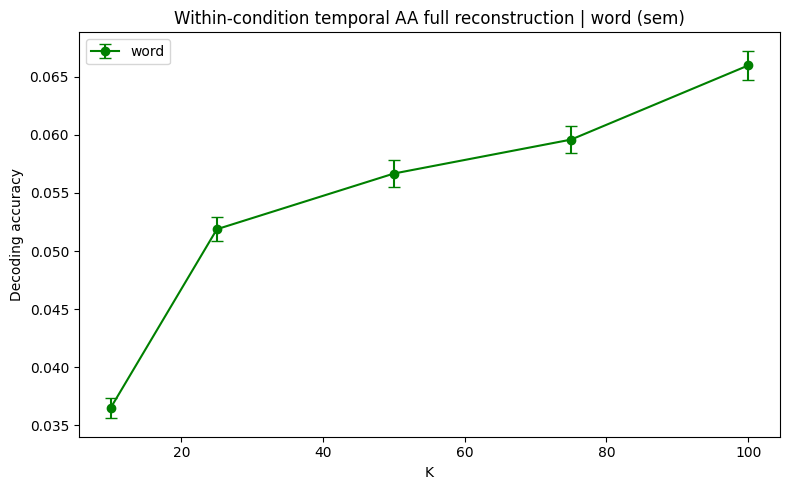

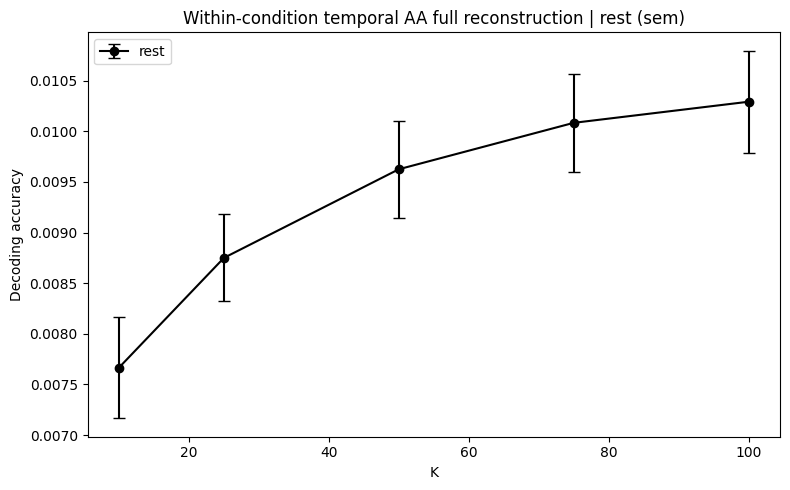

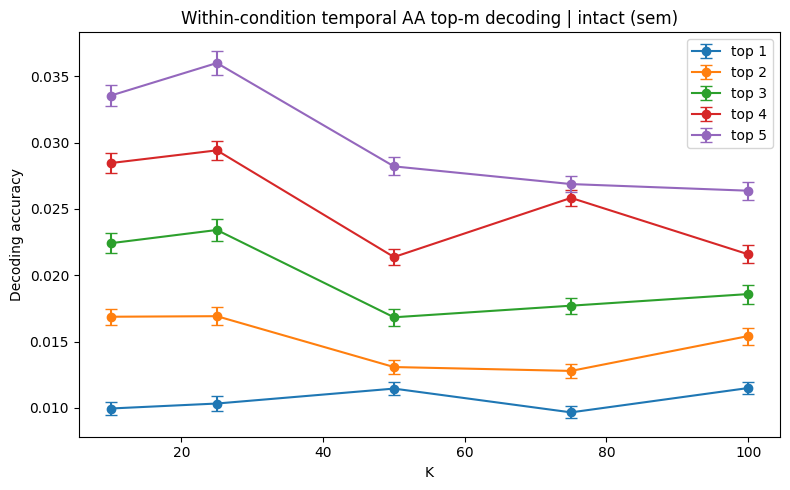

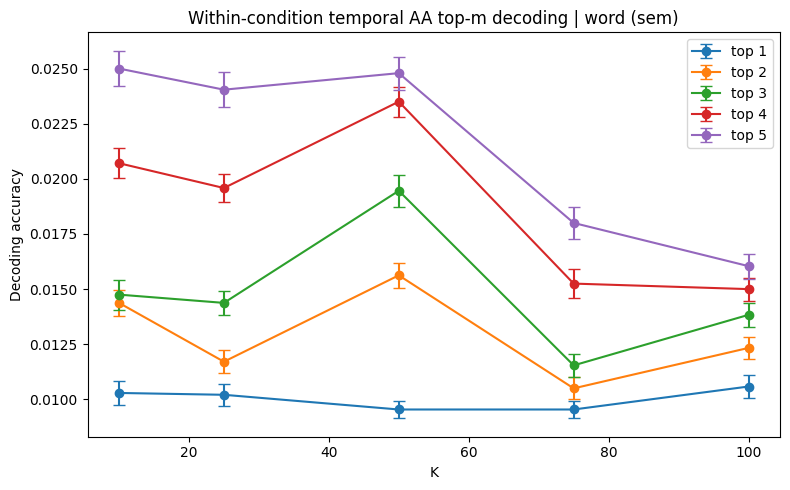

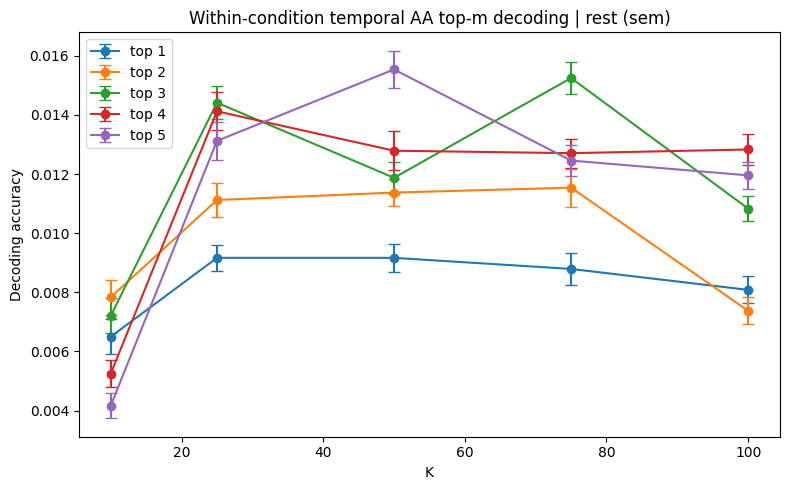

In [24]:

# Full reconstruction decoding curves
for cond_name in CONDITIONS:
    plt.figure(figsize=(8, 5))
    sub = full_summary[full_summary["condition"] == cond_name].sort_values("K")
    plt.errorbar(
        sub["K"], sub["mean"], yerr=sub["err"],
        marker="o", capsize=4, color=COND_PLOT_COLORS[cond_name], label=cond_name
    )
    plt.xlabel("K")
    plt.ylabel("Decoding accuracy")
    plt.title(f"Within-condition temporal AA full reconstruction | {cond_name} ({ERRORBAR_TYPE})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Top-m curves
for cond_name in CONDITIONS:
    plt.figure(figsize=(8, 5))
    cond_df = topm_summary[topm_summary["condition"] == cond_name].sort_values(["top_m", "K"])
    for top_m in sorted(cond_df["top_m"].unique()):
        sub = cond_df[cond_df["top_m"] == top_m].sort_values("K")
        plt.errorbar(sub["K"], sub["mean"], yerr=sub["err"], marker="o", capsize=4, label=f"top {top_m}")
    plt.xlabel("K")
    plt.ylabel("Decoding accuracy")
    plt.title(f"Within-condition temporal AA top-m decoding | {cond_name} ({ERRORBAR_TYPE})")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [25]:

OUTPUT_SUMMARY_DIR = "temporalAA_TRANSPOSED_within_decoding_summaries"
os.makedirs(OUTPUT_SUMMARY_DIR, exist_ok=True)

full_recon_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "full_reconstruction_runs.csv"), index=False)
topm_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "topm_runs.csv"), index=False)
per_arch_summary_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "per_archetype_mean_accuracy.csv"), index=False)
full_summary.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "full_reconstruction_summary.csv"), index=False)
topm_summary.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "topm_summary.csv"), index=False)
best_topm_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "best_topm_summary.csv"), index=False)
topm_archetypes_df.to_csv(os.path.join(OUTPUT_SUMMARY_DIR, "topm_archetype_identities.csv"), index=False)

np.save(os.path.join(OUTPUT_SUMMARY_DIR, "global_rankings_by_condition_K.npy"), global_rankings, allow_pickle=True)

print("Saved summaries to:", OUTPUT_SUMMARY_DIR)


Saved summaries to: temporalAA_TRANSPOSED_within_decoding_summaries
